# Exact sampling by coupling from the past

For an attractive binary model, monotonicity lets two extremal trajectories dominate all possible initial states. Coupling from the past reuses the same random updates while extending the starting time backward until the extremal chains coalesce at the present.

In [1]:
CHAPTER_DIR = "ch08"
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

CWD = Path.cwd()
if CWD.name.startswith("ch"):
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks").exists():
    NOTEBOOK_DIR = CWD / "notebooks" / CHAPTER_DIR
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(577)
NODE_COLOR = "#34495e"
NODE_TEXT_COLOR = "white"
plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 19,
})

def save_figure(fig, stem):
    for suffix, kwargs in [("pdf", {}), ("png", {"dpi": 240})]:
        path = FIG_DIR / f"{stem}.{suffix}"
        fig.savefig(path, bbox_inches="tight", **kwargs)
        print(f"Saved: {path}")


## Monotone heat-bath updates

We use a five-spin ferromagnetic chain. A random update is a pair $(i,u)$: update site $i$ and compare $u$ with the conditional probability of spin $+1$. The update is monotone in the neighboring spins.

median lookback 31.0 maximum 127


Saved: figs/ch08_03_cftp_depth_and_samples.pdf


Saved: figs/ch08_03_cftp_depth_and_samples.png


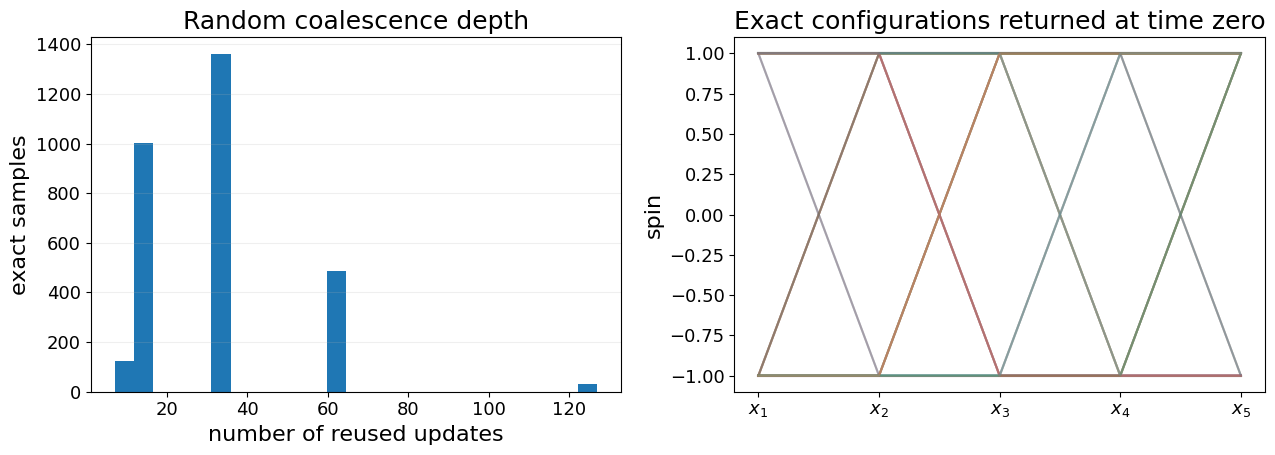

In [2]:
from itertools import product
n=5; beta=.55; J=.75; h=.08
def update(x,i,u):
    neigh=(x[i-1] if i>0 else 0)+(x[i+1] if i<n-1 else 0); p=1/(1+np.exp(-2*beta*(J*neigh+h))); y=x.copy(); y[i]=1 if u<p else -1; return y
def cftp_sample():
    T=1; randoms=[]
    while True:
        randoms=[(int(RNG.integers(n)),float(RNG.random())) for _ in range(T)]+randoms
        lo=-np.ones(n,dtype=int); hi=np.ones(n,dtype=int)
        for i,u in randoms: lo=update(lo,i,u); hi=update(hi,i,u)
        if np.array_equal(lo,hi): return lo.copy(),len(randoms)
        T*=2
samples=[]; depths=[]
for _ in range(3000): s,d=cftp_sample(); samples.append(s); depths.append(d)
samples=np.asarray(samples)
print('median lookback',np.median(depths),'maximum',np.max(depths))
fig,axes=plt.subplots(1,2,figsize=(13,4.8)); axes[0].hist(depths,bins=25); axes[0].set_xlabel('number of reused updates'); axes[0].set_ylabel('exact samples'); axes[0].set_title('Random coalescence depth'); axes[0].grid(axis='y',alpha=.2)
axes[1].plot(samples[:80].T,alpha=.18); axes[1].set_xticks(range(n),[rf'$x_{i+1}$' for i in range(n)]); axes[1].set_ylabel('spin'); axes[1].set_title('Exact configurations returned at time zero'); fig.tight_layout(); save_figure(fig,'ch08_03_cftp_depth_and_samples'); plt.show()

## Comparison with exact enumeration

Saved: figs/ch08_03_exact_marginal_check.pdf


Saved: figs/ch08_03_exact_marginal_check.png


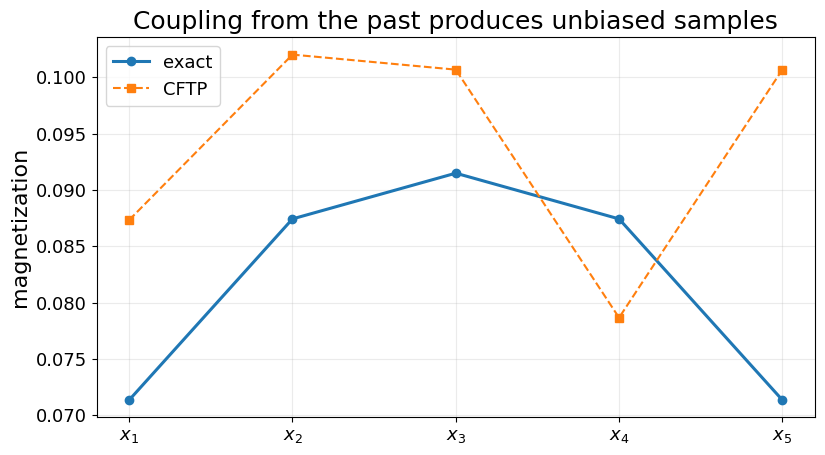

In [3]:
states=np.array(list(product([-1,1],repeat=n))); logweights=[]
for x in states: logweights.append(beta*(J*sum(x[i]*x[i+1] for i in range(n-1))+h*x.sum()))
w=np.exp(logweights); p=w/w.sum(); exact=np.sum(p[:,None]*states,axis=0); empirical=samples.mean(axis=0)
fig,ax=plt.subplots(figsize=(8.5,4.8)); idx=np.arange(n); ax.plot(idx,exact,marker='o',linewidth=2.2,label='exact'); ax.plot(idx,empirical,marker='s',linestyle='--',label='CFTP'); ax.set_xticks(idx,[rf'$x_{i+1}$' for i in range(n)]); ax.set_ylabel('magnetization'); ax.set_title('Coupling from the past produces unbiased samples'); ax.legend(); ax.grid(alpha=.25); fig.tight_layout(); save_figure(fig,'ch08_03_exact_marginal_check'); plt.show()

## Exercises

1. Prove monotonicity of the heat-bath update for $J\geq0$.
2. Increase $\beta$ and study the coalescence-depth distribution.
3. Explain why the two-extremal-chain shortcut fails for frustrated couplings.